This notebook demonstrates the approach used to generate the synthetic data used to evaluate SOCS. First, import several python packages.

In [1]:
import scvelo as scv
import numpy as np
import scanpy as sc
import anndata as ad
import h5py
import scipy.sparse as sparse
import pandas as pd
import squidpy as sq
import matplotlib.pyplot as plt
import shapely
import ot
from socs_r.analysis import map_vector_sampled,hillNumber_1,vec2vec
import geopandas as gpd
import copy

/projectnb/perturb-fish/jpbryan/.conda/envs/myEnv/lib/python3.12/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


We define a few functions used to transform spatial coordinates.

In [2]:
def affineTransform(vec,A,b):
    Ab = np.concatenate([A,b],axis=1)
    Ab1 = np.concatenate([Ab,np.zeros([1,3])])
    Ab1[2,2] = 1
    vec1 = np.concatenate([vec,np.ones([1,vec.shape[1]])])
    y1 = np.matmul(Ab1,vec1)
    return y1[:-1,:]
def sample_poly(poly,n_pts):
    xy_all = []
    gs = gpd.GeoSeries(poly)
    for x in range(n_pts):
        pt_x = gs.sample_points(1)
        xy_x = [pt_x[0].xy[0],pt_x[0].xy[1]] 
        xy_all.append(xy_x)
    xy_all = np.array(xy_all).squeeze()
    return xy_all

As a basis for gene expression data, we'll use the dentate gyrus scRNA-seq data included with the scVelo software package. We'll apply a few standard preprocessing steps.

In [3]:
adata_r = scv.datasets.dentategyrus()
adata_r.layers['raw_counts'] = np.array(adata_r.X.todense())
scv.pp.filter_genes(adata_r,min_shared_counts=20)
scv.pp.normalize_per_cell(adata_r)
scv.pp.filter_genes_dispersion(adata_r,n_top_genes=2000)
adata_r.layers['norm_counts'] = np.array(adata_r.X.todense())

Filtered out 10340 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.


Following the scVelo tutorial, we'll compute the RNA velocity.

In [4]:
scv.pp.moments(adata_r,n_neighbors=30,n_pcs=30)
scv.tl.velocity(adata_r,mode='steady_state')
adata_r.layers['velocity_norm'] = np.expm1(adata_r.layers['velocity'])

/scratch/428286.1.ood/ipykernel_2293438/2475295928.py:1: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_r,n_neighbors=30,n_pcs=30)
/projectnb/perturb-fish/jpbryan/.conda/envs/myEnv/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/projectnb/perturb-fish/jpbryan/.conda/envs/myEnv/lib/python3.12/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [5]:
adata_t1 = adata_r.copy()
adata_t2 = adata_r.copy()

We'll create two time point datasets. The first time point will use exactly the dentate gyrus gene expression data. The second time point will use that gene expression, plus a scaled version of the RNA velocity, representing advancement in time.

In [6]:
hVal = 10
adata_t1.X = adata_t1.layers['norm_counts']
adata_t2.X = adata_t2.layers['norm_counts']
V_t2 = adata_t2.layers['velocity_norm']
adata_t2.X = adata_t2.X+hVal*V_t2
adata_t2.X = (adata_t2.X>0)*adata_t2.X

For spatial coordinates, we will use as a basis the coordinates of the developing mouse heart from the MOSTA dataset (Chen et al., Cell 2022).

In [88]:
xy_t1 = np.load('heart_spatial_coords.npy')

In [89]:
inds_xy = np.random.choice(xy_t1.shape[0],adata_t1.shape[0],replace=False)
adata_t1.obsm['spatial'] = xy_t1[inds_xy,:]
adata_t2.obsm['spatial'] = xy_t1[inds_xy,:]

We'll define a independently-evolving structure, by drawing a circle and assigning the cells within that circle to the structure.

In [90]:
# Define a central spatial location for the circle-shaped structure, and a radius for the circle.
ctr = [195,-225]
dist_th = 10
# Calculate the distance from each cell to the circle center.
xy = adata_t2.obsm['spatial']
dists_xy_x = np.zeros([xy.shape[0],])
for y in range(xy.shape[0]):
    dists_xy_x[y] = np.linalg.norm(xy[y,:]-ctr)
# Sort cells into structures
adata_t1.obs['struct'] = 0
adata_t1.obs['struct'].iloc[dists_xy_x<dist_th] = 1
adata_t2.obs['struct'] = 0
adata_t2.obs['struct'].iloc[dists_xy_x<dist_th] = 1
adata_t2.obsm['spatial'][:,0] = adata_t2.obsm['spatial'][:,0]-np.mean(adata_t2.obsm['spatial'][:,0])
adata_t2.obsm['spatial'][:,1] = adata_t2.obsm['spatial'][:,1]-np.mean(adata_t2.obsm['spatial'][:,1])
xy = adata_t2.obsm['spatial']
xy_struct = xy[np.where(adata_t1.obs['struct']==1)[0],:]


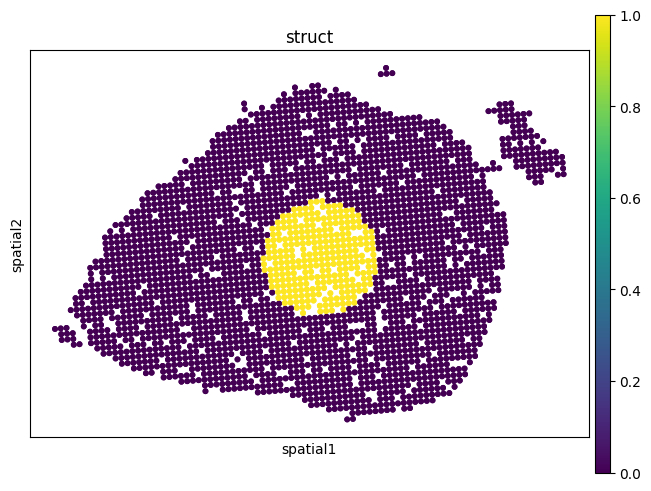

In [91]:
# Visualize the t1 dataset with the structure.
sq.pl.spatial_scatter(
    adata_t1,
    shape=None,
    library_id='spatial',
    color='struct'
)

We'll now transform the spatial coordinates of the second time point dataset. First, we'll define an affine transform matrix that we'll apply to all of the coordinates.

In [92]:
A_0 = np.array([[1.5,0.375],[0,1]])
b_0 = np.array([[0],[0]])
# Transform the spatial coordinates(
xy_t = affineTransform(xy.T,A_0,b_0).T
# set up transformed spatial coordinates as a list of shapely Point objects
mp_t = [shapely.Point(xy_t[x,:]) for x in range(xy_t.shape[0])]

Next, we'll apply a different transform to the defined structure.

In [93]:
A_struct = np.array([[0.75,0.1875],[0,0.75]])
b_struct = np.array([[10],[0]])
xy_struct_t = affineTransform(xy_struct.T,A_struct,b_struct).T
mp_struct_t = shapely.MultiPoint(xy_struct_t)
cvx_hull = shapely.convex_hull(mp_struct_t)

Now, we'll find the cells in the coordinates transformed by A_0 that do not overlap with the structure transformed by A_struct.

In [96]:
# We've previously drawn an outline around the transformed spatial coordinates (by A_0)
bounds_1 = pd.read_csv('example_data/dataset_1.csv')
bounds_1['Y'] = -bounds_1['Y']
bounds_2 = pd.read_csv('example_data/dataset_2.csv')
bounds_2['Y'] = -bounds_2['Y']
bounds_3 = pd.read_csv('example_data/dataset_3.csv')
bounds_3['Y'] = -bounds_3['Y']
bounds_4 = pd.read_csv('example_data/dataset_4.csv')
bounds_4['Y'] = -bounds_4['Y']
poly_1 = shapely.Polygon(bounds_1)
poly_2 = shapely.Polygon(bounds_2)
poly_3 = shapely.Polygon(bounds_3)
poly_4 = shapely.Polygon(bounds_4)
mpoly_h = shapely.MultiPolygon([poly_1,poly_2,poly_3,poly_4])
gs_h = gpd.GeoSeries(mpoly_h)

In [97]:
inds_surr = np.where(adata_t2.obs['struct']==0)[0]
ncells_surr = len(inds_surr)
mp_diff = mpoly_h.difference(cvx_hull)
xy_surr_i = sample_poly(mp_diff,ncells_surr)
C = ot.dist(xy_struct,xy_surr_i)
a = ot.utils.unif(ncells_surr)
sol = ot.solve_sample(adata_t2.obsm['spatial'][inds_surr,:],xy_surr_i,a,a)
P = sol.plan
inds_p = np.argmax(P,axis=1)
xy_surr_i_p = xy_surr_i[inds_p,:]

Now, we'll combine the t2 spatial coordinates transformed by A_0 and A_struct.

In [98]:
adata_t2.obsm['spatial'][adata_t2.obs['struct']==0,:] = xy_surr_i_p
adata_t2.obsm['spatial'][adata_t2.obs['struct']==1,:] = xy_struct_t

Now we can visualize the transformed t2 dataset:

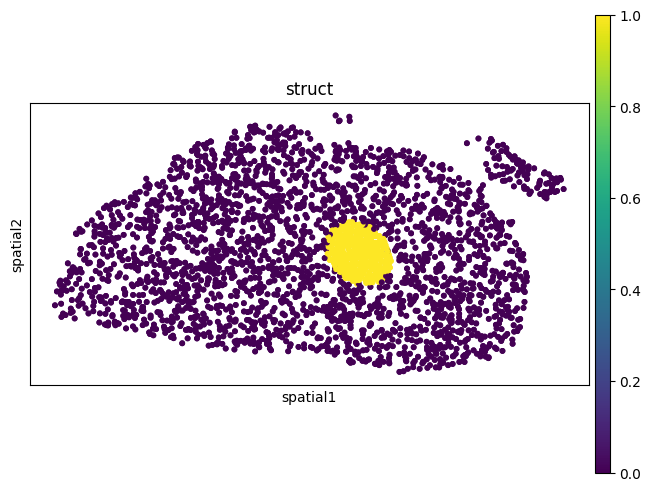

In [99]:
sq.pl.spatial_scatter(
    adata_t2,
    shape=None,
    library_id='spatial',
    color='struct'
)